In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df = pd.read_csv("../data/IPL.csv")
df.head()

C:\Users\M. LOKESH KUMAR\AppData\Local\Temp\ipykernel_13176\2272045059.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/IPL.csv")


,Unnamed: 0,match_id,date,Unnamed: 3,Unnamed: 4,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [ ]:
# Keep only first innings
df = df[df['innings'] == 1]

# Create overs completed column
df['overs_completed'] = df['over'] + df['ball']/6

# Current score
df['current_score'] = df['team_runs']

# Wickets lost
df['wickets_lost'] = df['team_wicket']

# Find final score of each match
final_scores = df.groupby('match_id')['team_runs'].max().reset_index()
final_scores.rename(columns={'team_runs': 'final_score'}, inplace=True)

# Merge final score with main dataframe
df = df.merge(final_scores, on='match_id')

# Select required features
data = df[['batting_team',
           'bowling_team',
           'venue',
           'overs_completed',
           'current_score',
           'wickets_lost',
           'final_score']]

# Remove very early overs for stable prediction
data = data[data['overs_completed'] > 5]

# View dataset
data.head()

,batting_team,bowling_team,venue,overs_completed,current_score,wickets_lost,final_score
32,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,5.166667,61,0,222
33,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,5.333333,61,1,222
34,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,5.500000,61,1,222
35,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,5.666667,61,1,222
36,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,5.833333,61,1,222


In [ ]:
# Unique batting team names
print("Unique Batting Teams:")
print(sorted(df['batting_team'].unique()))
print("\nTotal Batting Teams:", df['batting_team'].nunique())

print("\n-------------------------\n")

# Unique bowling team names
print("Unique Bowling Teams:")
print(sorted(df['bowling_team'].unique()))
print("\nTotal Bowling Teams:", df['bowling_team'].nunique())

print("\n-------------------------\n")

# Unique venue names
print("Unique Venues:")
print(sorted(df['venue'].unique()))
print("\nTotal Venues:", df['venue'].nunique())

Unique Batting Teams:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Total Batting Teams: 19

-------------------------

Unique Bowling Teams:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Total Bowling Teams: 19

-------------------------

Unique Venues:
[

In [ ]:
# Unique batting team names
batting_teams = sorted(df['batting_team'].unique())

print("Unique Batting Teams:")
for team in batting_teams:
    print(team)

print("\nTotal Batting Teams:", len(batting_teams))


print("\n---------------------------------\n")


# Unique bowling team names
bowling_teams = sorted(df['bowling_team'].unique())

print("Unique Bowling Teams:")
for team in bowling_teams:
    print(team)

print("\nTotal Bowling Teams:", len(bowling_teams))

Unique Batting Teams:
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Rising Pune Supergiants
Royal Challengers Bangalore
Royal Challengers Bengaluru
Sunrisers Hyderabad

Total Batting Teams: 19

---------------------------------

Unique Bowling Teams:
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiant
Rising Pune Supergiants
Royal Challengers Bangalore
Royal Challengers Bengaluru
Sunrisers Hyderabad

Total Bowling Teams: 19


In [ ]:
team_mapping = {
'Delhi Daredevils': 'Delhi Capitals',
'Kings XI Punjab': 'Punjab Kings',
'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)
print(sorted(df['batting_team'].unique()))
print("Total Teams:", df['batting_team'].nunique())

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
Total Teams: 15


In [ ]:
old_teams = [
'Deccan Chargers',
'Kochi Tuskers Kerala',
'Pune Warriors',
'Gujarat Lions',
'Rising Pune Supergiants'
]

df = df[~df['batting_team'].isin(old_teams)]
df = df[~df['bowling_team'].isin(old_teams)]
print(sorted(df['batting_team'].unique()))
print("Total Teams:", df['batting_team'].nunique())

['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
Total Teams: 10


In [ ]:
# Step 1: Remove city names after comma
df['venue'] = df['venue'].str.split(',').str[0]

# Step 2: Fix formatting differences
venue_mapping = {
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association Stadium',
    'Dr DY Patil Sports Academy': 'Dr DY Patil Sports Academy',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'ACA-VDCA Cricket Stadium',
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi International Stadium',
    'MA Chidambaram Stadium': 'MA Chidambaram Stadium',
    'Maharashtra Cricket Association Stadium': 'Maharashtra Cricket Association Stadium'
}

df['venue'] = df['venue'].replace(venue_mapping)

# Step 3: Check cleaned venues
venues = sorted(df['venue'].unique())

print("Cleaned Venue Names:\n")
for v in venues:
    print(v)

print("\nTotal Venues:", len(venues))

Cleaned Venue Names:

ACA-VDCA Cricket Stadium
Arun Jaitley Stadium
Barabati Stadium
Barsapara Cricket Stadium
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium
Brabourne Stadium
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dubai International Cricket Stadium
Eden Gardens
Feroz Shah Kotla
Himachal Pradesh Cricket Association Stadium
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
MA Chidambaram Stadium
Maharaja Yadavindra Singh International Cricket Stadium
Maharashtra Cricket Association Stadium
Narendra Modi Stadium
New Wanderers Stadium
Newlands
OUTsurance Oval
Punjab Cricket Association Stadium
Rajiv Gandhi International Stadium
Sardar Patel Stadium
Sawai Mansingh Stadium
Shaheed Veer Narayan Singh International Stadium
Sharjah Cricket Stadium
Sheikh Zayed Stadium
St George's Park
Subrata Roy Sahara Stadium
SuperSport Park
Wankhede Stadium
Zayed Cricket Stadium

Total Venues: 36


In [ ]:
df['venue'] = df['venue'].replace({
    'Feroz Shah Kotla': 'Arun Jaitley Stadium'
})
print(sorted(df['venue'].unique()))
print("Total Venues:", df['venue'].nunique())

['ACA-VDCA Cricket Stadium', 'Arun Jaitley Stadium', 'Barabati Stadium', 'Barsapara Cricket Stadium', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium', 'Brabourne Stadium', 'Buffalo Park', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Himachal Pradesh Cricket Association Stadium', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'Maharaja Yadavindra Singh International Cricket Stadium', 'Maharashtra Cricket Association Stadium', 'Narendra Modi Stadium', 'New Wanderers Stadium', 'Newlands', 'OUTsurance Oval', 'Punjab Cricket Association Stadium', 'Rajiv Gandhi International Stadium', 'Sardar Patel Stadium', 'Sawai Mansingh Stadium', 'Shaheed Veer Narayan Singh International Stadium', 'Sharjah Cricket Stadium', 'Sheikh Zayed Stadium', "St George's Park", 'Subrata Roy Sahara Stadium', 'SuperSport Park', 'Wankhede Stadium', 'Zayed Cri

In [ ]:
df = df[df['innings'] == 1]

print(df.shape)

(121408, 68)


In [ ]:
# Step 1: calculate final score of each match (first innings)
final_scores = df.groupby('match_id')['team_runs'].max().reset_index()

# Step 2: rename column
final_scores.rename(columns={'team_runs': 'final_score'}, inplace=True)

# Step 3: merge with main dataframe
df = df.merge(final_scores, on='match_id', how='left')

# Step 4: verify
df[['match_id','team_runs','final_score']].head()

KeyError: "['final_score'] not in index"

In [ ]:
# overs completed (example: 10.3 overs)
df['overs_completed'] = df['over'] + df['ball']/6

# current score
df['current_score'] = df['team_runs']

# wickets lost
df['wickets_lost'] = df['team_wicket']

# check
df[['over','ball','overs_completed','current_score','wickets_lost']].head()

,over,ball,overs_completed,current_score,wickets_lost
0,0,1,0.166667,1,0
1,0,2,0.333333,1,0
2,0,3,0.500000,2,0
3,0,3,0.500000,2,0
4,0,4,0.666667,2,0


In [ ]:
# keep only end of over data
df = df[df['ball'] == 6]

# check shape
print(df.shape)

# preview
df[['over','ball','current_score','wickets_lost','final_score']].head()

(20207, 70)


,over,ball,current_score,wickets_lost,final_score
6,0,6,3,0,222
12,1,6,21,0,222
18,2,6,27,0,222
25,3,6,50,0,222
31,4,6,60,0,222


In [ ]:
df = df.reset_index(drop=True)
df[['over','ball','current_score','wickets_lost','final_score']].head()

,over,ball,current_score,wickets_lost,final_score
0,0,6,3,0,222
1,1,6,21,0,222
2,2,6,27,0,222
3,3,6,50,0,222
4,4,6,60,0,222


In [ ]:
df['current_run_rate'] = df['current_score'] / df['overs_completed']
# balls completed
df['balls_completed'] = (df['overs_completed'].astype(int) * 6) + ((df['overs_completed'] % 1) * 10)

# balls remaining in innings
df['balls_remaining'] = 120 - df['balls_completed']

# effective batting depth (assume top 7 can bat well)
df['effective_wickets'] = (7 - df['wickets_lost']).clip(lower=0)

# phase of innings
def get_phase(over):
    if over <= 6:
        return "powerplay"
    elif over <= 15:
        return "middle"
    else:
        return "death"

df['phase'] = df['overs_completed'].apply(get_phase)

In [ ]:
# calculate venue average for first innings scores
venue_first_avg = df.groupby('venue')['final_score'].mean().reset_index()

# rename column
venue_first_avg.rename(columns={'final_score':'venue_first_innings_avg'}, inplace=True)

# merge with main dataframe
df = df.merge(venue_first_avg, on='venue', how='left')

# check
df[['venue','venue_first_innings_avg']].head()

,venue,venue_first_innings_avg
0,M Chinnaswamy Stadium,174.571593
1,M Chinnaswamy Stadium,174.571593
2,M Chinnaswamy Stadium,174.571593
3,M Chinnaswamy Stadium,174.571593
4,M Chinnaswamy Stadium,174.571593


In [ ]:
df[['venue','venue_first_innings_avg']].drop_duplicates().head(10)

,venue,venue_first_innings_avg
0,M Chinnaswamy Stadium,174.571593
20,Punjab Cricket Association Stadium,170.255963
40,Arun Jaitley Stadium,173.955429
60,Wankhede Stadium,173.479175
81,Sawai Mansingh Stadium,166.829003
100,MA Chidambaram Stadium,164.754519
230,Eden Gardens,171.766003
332,Dr DY Patil Sports Academy,169.165703
883,Newlands,141.173913
935,St George's Park,161.596774


In [ ]:
# remove old column if it exists
df = df.drop(columns=['venue_first_innings_avg'], errors='ignore')

In [ ]:
# convert date column
df['date'] = pd.to_datetime(df['date'])

# extract year
df['year'] = df['date'].dt.year

# filter last 3 IPL seasons
recent_df = df[df['year'].isin([2023, 2024, 2025])]

# compute venue average
venue_first_avg = recent_df.groupby('venue')['final_score'].mean()

# assign averages using map
df['venue_first_innings_avg'] = df['venue'].map(venue_first_avg)

# check
df[['venue','venue_first_innings_avg']].drop_duplicates().head(15)

,venue,venue_first_innings_avg
0,M Chinnaswamy Stadium,190.886598
20,Punjab Cricket Association Stadium,198.169811
40,Arun Jaitley Stadium,200.984962
60,Wankhede Stadium,188.367580
81,Sawai Mansingh Stadium,187.788571
100,MA Chidambaram Stadium,168.975758
230,Eden Gardens,197.568807
332,Dr DY Patil Sports Academy,NaN
883,Newlands,NaN
935,St George's Park,NaN


In [ ]:
recent_venues_avg = venue_first_avg.sort_values(ascending=False)

for venue, avg in recent_venues_avg.items():
    print(f"{venue} : {round(avg,2)}")

ACA-VDCA Cricket Stadium : 209.53
Arun Jaitley Stadium : 200.98
Himachal Pradesh Cricket Association Stadium : 200.29
Punjab Cricket Association Stadium : 198.17
Eden Gardens : 197.57
Narendra Modi Stadium : 195.99
M Chinnaswamy Stadium : 190.89
Rajiv Gandhi International Stadium : 189.5
Wankhede Stadium : 188.37
Sawai Mansingh Stadium : 187.79
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium : 175.83
Barsapara Cricket Stadium : 175.27
Maharaja Yadavindra Singh International Cricket Stadium : 172.51
MA Chidambaram Stadium : 168.98


In [ ]:
df = df.drop(columns=[
    'final_score_x',
    'final_score_y',
    'venue_first_innings_avg_x',
    'venue_first_innings_avg_y'
], errors='ignore')

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'match_id', 'date', 'Unnamed: 3', 'Unnamed: 4', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out', 'overs_completed', 'cu

In [ ]:
X = df[['batting_team',
        'bowling_team',
        'venue',
        'overs_completed',
        'current_score',
        'wickets_lost',
        'current_run_rate',
        'venue_first_innings_avg']]

y = df['final_score']

In [ ]:
X = pd.get_dummies(X, columns=['batting_team','bowling_team','venue'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 11.505940367706543


In [ ]:
import pickle

pickle.dump(model, open('score_prediction_model.pkl', 'wb'))
pickle.dump(X.columns, open('model_columns.pkl', 'wb'))

In [ ]:
import pickle
import pandas as pd

# load trained model
model = pickle.load(open('score_prediction_model.pkl','rb'))

# load column structure
model_columns = pickle.load(open('model_columns.pkl','rb'))

In [ ]:
def predict_score(batting_team, bowling_team, venue,
                  overs_completed, current_score, wickets_lost,
                  venue_first_innings_avg):

    # calculate current run rate
    current_run_rate = current_score / overs_completed

    # create input dataframe
    input_df = pd.DataFrame({
        'batting_team':[batting_team],
        'bowling_team':[bowling_team],
        'venue':[venue],
        'overs_completed':[overs_completed],
        'current_score':[current_score],
        'wickets_lost':[wickets_lost],
        'current_run_rate':[current_run_rate],
        'venue_first_innings_avg':[venue_first_innings_avg]
    })

    # convert categorical features
    input_df = pd.get_dummies(input_df)

    # align columns with training data
    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    # prediction
    prediction = model.predict(input_df)

    return round(prediction[0])

In [ ]:
predict_score(
    batting_team="Royal Challengers Bengaluru",
    bowling_team="Mumbai Indians",
    venue="M Chinnaswamy Stadium",
    overs_completed=10,
    current_score=95,
    wickets_lost=2,
    venue_first_innings_avg=190
)

199

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Mean Absolute Error
mae = mean_absolute_error(y_test, predictions)

# Mean Squared Error
mse = mean_squared_error(y_test, predictions)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, predictions)

print("Model Evaluation Metrics")
print("-------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Model Evaluation Metrics
-------------------------
Mean Absolute Error (MAE): 11.51
Mean Squared Error (MSE): 294.13
Root Mean Squared Error (RMSE): 17.15
R² Score: 0.717


In [ ]:
#LINEAR REGRESSION
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fill missing venue averages
df['venue_first_innings_avg'] = df['venue_first_innings_avg'].fillna(df['venue_first_innings_avg'].mean())

# Feature selection
X = df[['batting_team',
        'bowling_team',
        'venue',
        'overs_completed',
        'current_score',
        'wickets_lost',
        'current_run_rate',
        'venue_first_innings_avg',
        'balls_remaining',
        'effective_wickets',
        'phase']]

y = df['final_score']

# Encode categorical features
X = pd.get_dummies(X, columns=['batting_team','bowling_team','venue'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Linear Regression Model Evaluation")
print("----------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Linear Regression Model Evaluation
----------------------------------
Mean Absolute Error (MAE): 15.58
Mean Squared Error (MSE): 443.63
Root Mean Squared Error (RMSE): 21.06
R² Score: 0.573


In [ ]:
#decision tree
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fill missing venue averages
df['venue_first_innings_avg'] = df['venue_first_innings_avg'].fillna(df['venue_first_innings_avg'].mean())

# Feature selection
X = df[['batting_team',
        'bowling_team',
        'venue',
        'overs_completed',
        'current_score',
        'wickets_lost',
        'current_run_rate',
        'venue_first_innings_avg']]

y = df['final_score']

# Encode categorical variables
X = pd.get_dummies(X, columns=['batting_team','bowling_team','venue'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Decision Tree Model Evaluation")
print("--------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Decision Tree Model Evaluation
--------------------------------
Mean Absolute Error (MAE): 13.53
Mean Squared Error (MSE): 533.49
Root Mean Squared Error (RMSE): 23.10
R² Score: 0.486


In [ ]:
#XgBoost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Fill missing venue averages
df['venue_first_innings_avg'] = df['venue_first_innings_avg'].fillna(df['venue_first_innings_avg'].mean())

# Feature selection
X = df[['batting_team',
        'bowling_team',
        'venue',
        'overs_completed',
        'current_score',
        'wickets_lost',
        'current_run_rate',
        'venue_first_innings_avg']]

y = df['final_score']

# Encode categorical variables
X = pd.get_dummies(X, columns=['batting_team','bowling_team','venue'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("XGBoost Model Evaluation")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

XGBoost Model Evaluation
------------------------
Mean Absolute Error (MAE): 12.41
Mean Squared Error (MSE): 296.46
Root Mean Squared Error (RMSE): 17.22
R² Score: 0.715


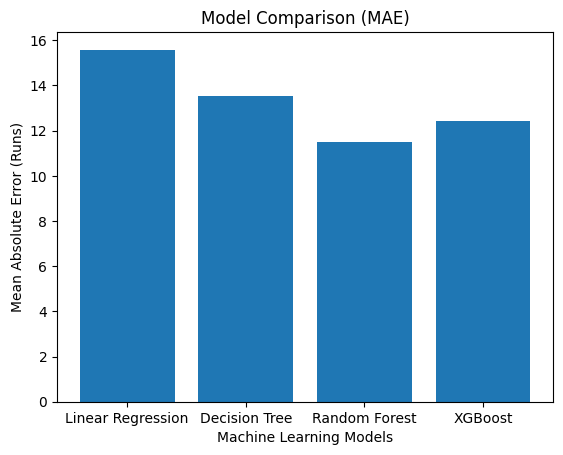

In [ ]:
import matplotlib.pyplot as plt

# MAE values from your models
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
mae_values = [15.58, 13.53, 11.51, 12.41]

plt.figure()

plt.bar(models, mae_values)

plt.title("Model Comparison (MAE)")
plt.xlabel("Machine Learning Models")
plt.ylabel("Mean Absolute Error (Runs)")

plt.show()

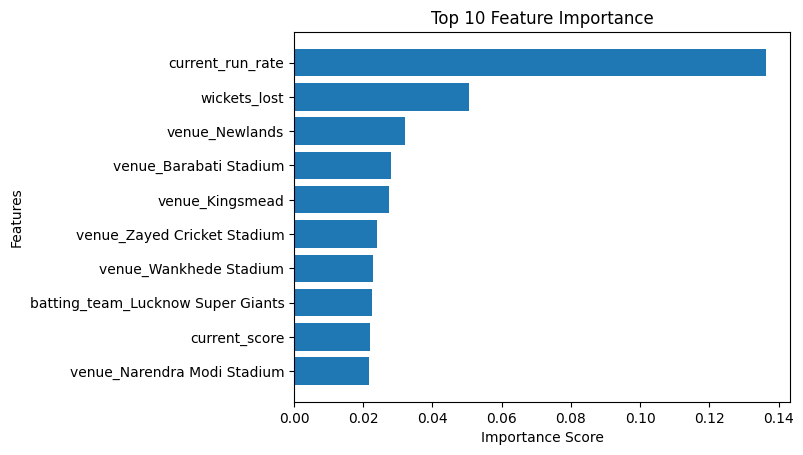

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# get feature importance
importance = model.feature_importances_

# convert to dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# plot top 10 important features
plt.figure()

plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

C:\Users\M. LOKESH KUMAR\AppData\Local\Temp\ipykernel_4704\1951054697.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_recent['venue_first_innings_avg'] = df_recent['venue_first_innings_avg'].fillna(df_recent['venue_first_innings_avg'].mean())


Random Forest Model Evaluation (Last 3 Years)
----------------------------------------------
Mean Absolute Error (MAE): 8.75
Mean Squared Error (MSE): 185.73
Root Mean Squared Error (RMSE): 13.63
R² Score: 0.845


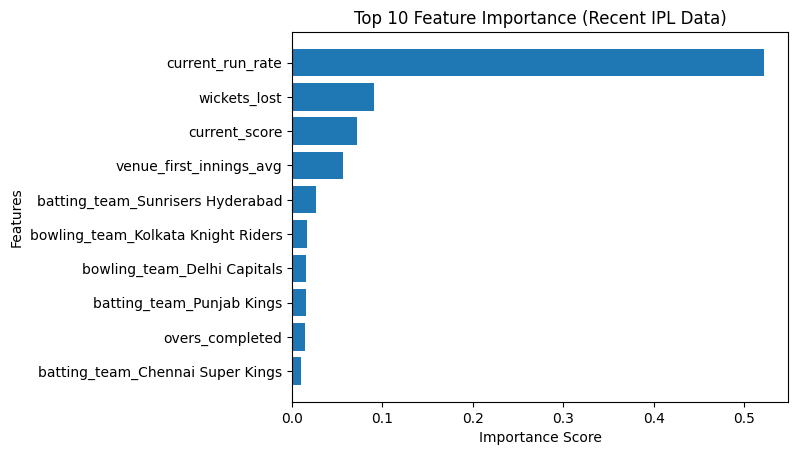

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Keep only last 3 IPL seasons
df_recent = df[df['year'].isin([2023, 2024, 2025])]

# Handle missing venue averages
df_recent['venue_first_innings_avg'] = df_recent['venue_first_innings_avg'].fillna(df_recent['venue_first_innings_avg'].mean())

# Feature selection
X = df_recent[['batting_team',
               'bowling_team',
               'venue',
               'overs_completed',
               'current_score',
               'wickets_lost',
               'current_run_rate',
               'venue_first_innings_avg']]

y = df_recent['final_score']

# Encode categorical features
X = pd.get_dummies(X, columns=['batting_team','bowling_team','venue'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Random Forest Model Evaluation (Last 3 Years)")
print("----------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

# Feature importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure()
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.title("Top 10 Feature Importance (Recent IPL Data)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print(sorted(df_recent['venue'].unique()))

['ACA-VDCA Cricket Stadium', 'Arun Jaitley Stadium', 'Barsapara Cricket Stadium', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium', 'Eden Gardens', 'Himachal Pradesh Cricket Association Stadium', 'M Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'Maharaja Yadavindra Singh International Cricket Stadium', 'Narendra Modi Stadium', 'Punjab Cricket Association Stadium', 'Rajiv Gandhi International Stadium', 'Sawai Mansingh Stadium', 'Wankhede Stadium']


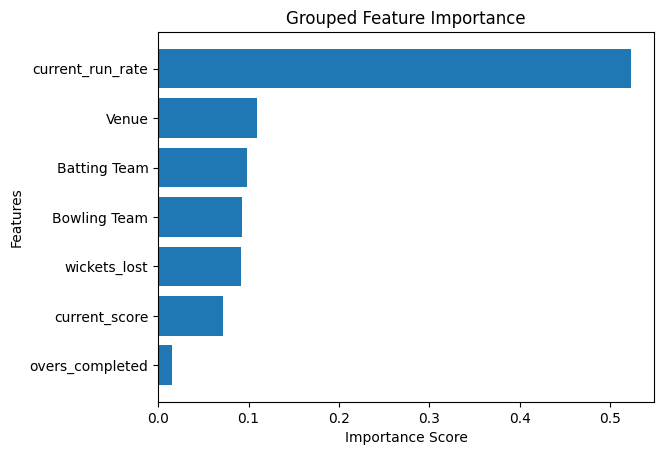

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Group features
feature_importance['Feature_Group'] = feature_importance['Feature'].apply(
    lambda x: 'Batting Team' if x.startswith('batting_team')
    else 'Bowling Team' if x.startswith('bowling_team')
    else 'Venue' if x.startswith('venue_')
    else x
)

# Sum grouped importance
grouped_importance = feature_importance.groupby('Feature_Group')['Importance'].sum().reset_index()

# Sort values
grouped_importance = grouped_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()

plt.barh(grouped_importance['Feature_Group'], grouped_importance['Importance'])

plt.title("Grouped Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

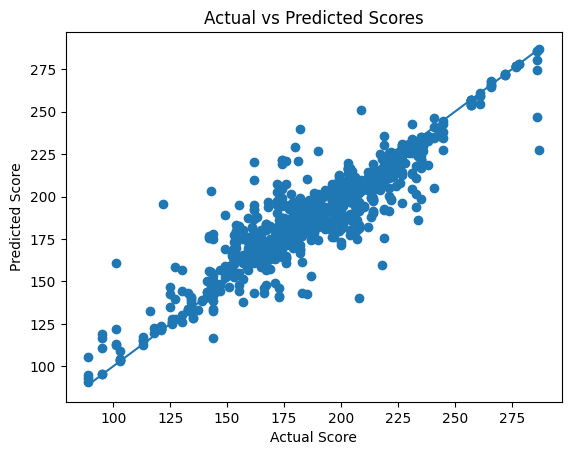

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, predictions)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

# ideal prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [ ]:
import pickle

# save trained model
pickle.dump(model, open("ipl_score_prediction_model.pkl", "wb"))

# save feature columns
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

print("Model and columns saved successfully!")

Model and columns saved successfully!


In [ ]:
#Xgboosr 2023-25
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Use only last 3 IPL seasons
df_recent = df[df['year'].isin([2023, 2024, 2025])]

# Handle missing venue averages
df_recent['venue_first_innings_avg'] = df_recent['venue_first_innings_avg'].fillna(
    df_recent['venue_first_innings_avg'].mean()
)

# Feature selection
X = df_recent[['batting_team',
               'bowling_team',
               'venue',
               'overs_completed',
               'current_score',
               'wickets_lost',
               'current_run_rate',
               'venue_first_innings_avg']]

y = df_recent['final_score']

# One-hot encoding
X = pd.get_dummies(X, columns=['batting_team','bowling_team','venue'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost model
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb.fit(X_train, y_train)

# Predictions
predictions = model_xgb.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("XGBoost Model Evaluation (Last 3 Years)")
print("----------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

C:\Users\M. LOKESH KUMAR\AppData\Local\Temp\ipykernel_4704\3210779310.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_recent['venue_first_innings_avg'] = df_recent['venue_first_innings_avg'].fillna(


XGBoost Model Evaluation (Last 3 Years)
----------------------------------------
Mean Absolute Error (MAE): 8.99
Mean Squared Error (MSE): 172.13
Root Mean Squared Error (RMSE): 13.12
R² Score: 0.856


In [ ]:
print(len(model_columns))

60


In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# -----------------------------
# FEATURES
# -----------------------------

X = df[['batting_team',
        'bowling_team',
        'venue',
        'overs_completed',
        'current_score',
        'wickets_lost',
        'current_run_rate']]

# -----------------------------
# TARGET
# -----------------------------

y = df['final_score']   # change only if column name different

# -----------------------------
# ONE HOT ENCODING
# -----------------------------

X = pd.get_dummies(X)

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# MODEL
# -----------------------------

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# PREDICTION
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# METRICS
# -----------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae,2))
print("MSE:", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,3))

# -----------------------------
# SAVE MODEL
# -----------------------------

pickle.dump(model, open("score_prediction_model.pkl","wb"))
pickle.dump(X.columns, open("model_columns.pkl","wb"))

print("Model saved successfully")

KeyError: 'final_score'

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Venue Averages (recent seasons):
  ACA-VDCA Cricket Stadium : 211.03
  Himachal Pradesh Cricket Association Stadium : 203.56
  Arun Jaitley Stadium : 201.55
  Punjab Cricket Association Stadium : 198.28
  Eden Gardens : 197.75
  Narendra Modi Stadium : 196.26
  M Chinnaswamy Stadium : 191.75
  Rajiv Gandhi International Stadium : 190.35
  Wankhede Stadium : 188.04
  Sawai Mansingh Stadium : 187.93
  Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium : 176.01
  Barsapara Cricket Stadium : 174.79
  Maharaja Yadavindra Singh International Cricket Stadium : 173.37
  MA Chidambaram Stadium : 168.58

Quality batting remaining by wickets lost:
  0 wickets lost → 100.0% quality batting left
  1 wickets lost → 82.0% quality batting left
  2 wickets lost → 64.0% qu

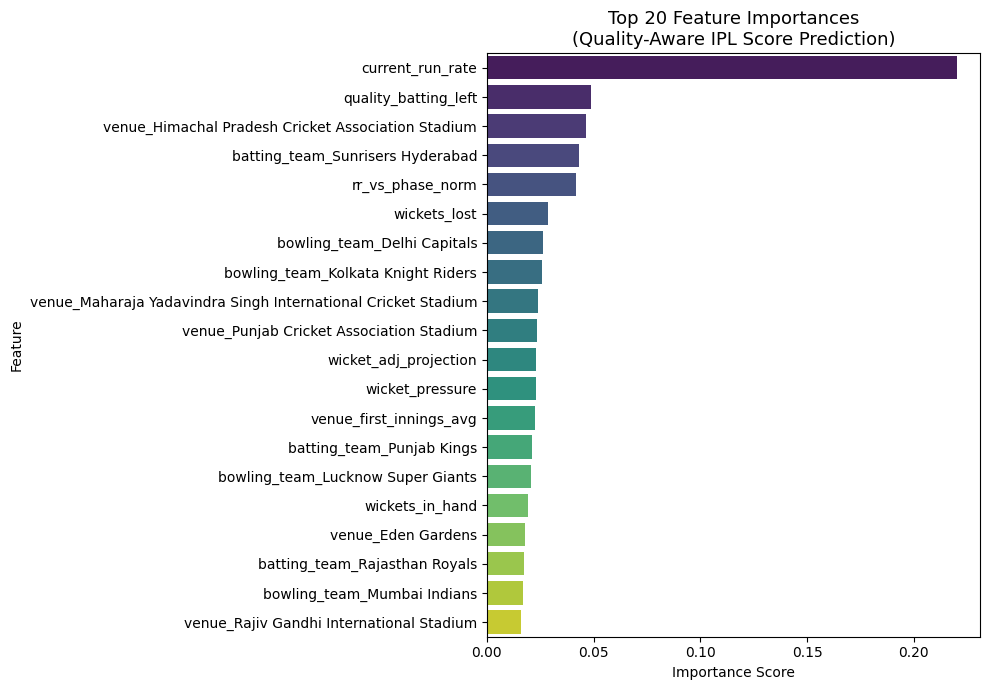

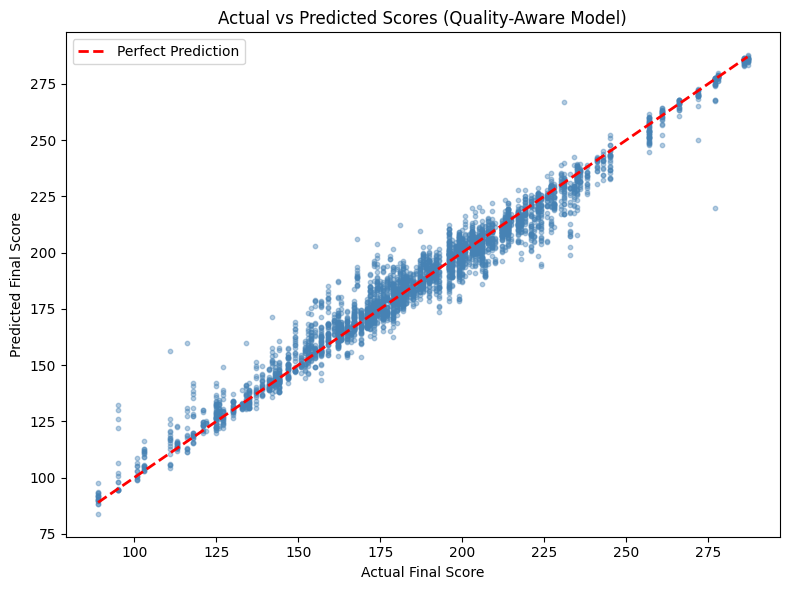


Model and columns saved successfully!

  Mumbai Indians vs Chennai Super Kings
  Venue   : Wankhede Stadium
  Score   : 110/2 in 10 overs
  CRR     : 11.00  |  Phase: Middle
  Quality batting left    : 64.0%
  Naive CRR projection    : 220
  Quality-adj projection  : 180
  ── Predicted Final Score: 198 ──


  Mumbai Indians vs Chennai Super Kings
  Venue   : Wankhede Stadium
  Score   : 100/5 in 10 overs
  CRR     : 10.00  |  Phase: Middle
  Quality batting left    : 20.0%
  Naive CRR projection    : 200
  Quality-adj projection  : 120
  ── Predicted Final Score: 170 ──


  Royal Challengers Bengaluru vs Kolkata Knight Riders
  Venue   : M Chinnaswamy Stadium
  Score   : 50/3 in 10 overs
  CRR     : 5.00  |  Phase: Middle
  Quality batting left    : 47.0%
  Naive CRR projection    : 100
  Quality-adj projection  : 74
  ── Predicted Final Score: 130 ──


  Delhi Capitals vs Rajasthan Royals
  Venue   : Arun Jaitley Stadium
  Score   : 63/4 in 7 overs
  CRR     : 9.00  |  Phase: Middle


171

In [ ]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ----------------------------
# Features used for training
# ----------------------------
FEATURES = [
    "batting_team_strength",
    "bowling_team_strength",
    "venue_first_innings_avg",
    "overs_completed",
    "current_score",
    "wickets_lost",
    "wickets_in_hand",
    "current_run_rate",
    "crr_wicket_index",
    "balls_per_wicket",
    "balls_remaining",
    "projected_score",
    "runs_to_venue_avg",
    "game_phase",
    "quality_batting_left",
    "wicket_adj_projection",
    "wicket_pressure",
    "rr_vs_phase_norm"
]

TARGET = "final_score"

# ----------------------------
# Train Test Split
# ----------------------------
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# Train Model
# ----------------------------
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# Evaluate
# ----------------------------
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)

print("Model MAE:", round(mae,2))

# ----------------------------
# Save Artifacts
# ----------------------------
pickle.dump(model, open("ipl_score_model.pkl", "wb"))
pickle.dump(FEATURES, open("model_columns.pkl", "wb"))
pickle.dump(quality_remaining, open("quality_remaining.pkl", "wb"))

# Encoders bundle
encoders = {
    "teams": TEAMS,
    "venues": VENUES,
    "batting_strength": batting_enc,
    "bowling_strength": bowling_enc,
    "venue_avg": venue_enc,
    "global_avg": 160
}

pickle.dump(encoders, open("ipl_encoders.pkl", "wb"))

print("Artifacts saved successfully")

In [ ]:
import pickle

enc = pickle.load(open("ipl_encoders.pkl","rb"))

print(enc.keys())

dict_keys(['batting_enc', 'bowling_enc', 'venue_enc', 'global_avg'])


In [ ]:
encoders = {
    "teams": TEAMS,
    "venues": VENUES,
    "batting_strength": batting_enc,
    "bowling_strength": bowling_enc,
    "venue_avg": venue_enc,
    "global_avg": 160
}

NameError: name 'TEAMS' is not defined

In [ ]:
df = pd.read_csv("../data/IPL.csv", low_memory=False)

# Force clean column name - handle case where previous cells made final_score_x etc
if 'final_score_x' in df.columns:
    df = df.rename(columns={'final_score_x': 'final_score'})
if 'final_score_y' in df.columns:
    df = df.drop(columns=['final_score_y'], errors='ignore')

In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Active IPL teams (current 10 franchises only) ────────────────────────────
TEAMS = sorted([
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bengaluru',
    'Sunrisers Hyderabad'
])

# ── Active IPL venues (only venues used in 2023-25) ──────────────────────────
VENUES = sorted([
    'ACA-VDCA Cricket Stadium',
    'Arun Jaitley Stadium',
    'Barsapara Cricket Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium',
    'Dr DY Patil Sports Academy',
    'Eden Gardens',
    'Himachal Pradesh Cricket Association Stadium',
    'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium',
    'Maharashtra Cricket Association Stadium',
    'Narendra Modi Stadium',
    'Punjab Cricket Association Stadium',
    'Rajiv Gandhi International Stadium',
    'Sawai Mansingh Stadium',
    'Wankhede Stadium'
])

# ── Target encoding: team batting/bowling strength ────────────────────────────
batting_enc = df.groupby('batting_team')['final_score'].mean()
bowling_enc = df.groupby('bowling_team')['final_score'].mean()
venue_enc   = df.groupby('venue')['final_score'].mean()
global_avg  = float(df['final_score'].mean())

df['batting_team_strength'] = df['batting_team'].map(batting_enc).fillna(global_avg)
df['bowling_team_strength'] = df['bowling_team'].map(bowling_enc).fillna(global_avg)

# ── Quality Batting Left ──────────────────────────────────────────────────────
# Top 5 batters contribute ~80% of runs. Tail barely scores.
# 100/5 is NOT the same as 100/2 even if CRR is the same.
position_weights = [0.18, 0.18, 0.17, 0.15, 0.12, 0.08, 0.05, 0.03, 0.02, 0.02]
quality_remaining = {wkts: round(sum(position_weights[wkts:]), 4) for wkts in range(10)}

print("Quality batting remaining:")
for k, v in quality_remaining.items():
    print(f"  {k} wickets lost → {v*100:.1f}% quality left")

df['quality_batting_left'] = df['wickets_lost'].map(quality_remaining).fillna(0.0)

# ── Game Phase ────────────────────────────────────────────────────────────────
def get_phase(overs):
    if overs <= 6:    return 0   # Powerplay
    elif overs <= 15: return 1   # Middle
    else:             return 2   # Death

df['game_phase']      = df['overs_completed'].apply(get_phase)
df['balls_remaining'] = (20 - df['overs_completed']) * 6
df['wickets_in_hand'] = 10 - df['wickets_lost']

# ── Wicket-Adjusted Projection ───────────────────────────────────────────────
df['wicket_adj_projection'] = (
    df['current_score'] +
    (df['balls_remaining'] / 6) * df['current_run_rate'] * df['quality_batting_left']
)

# ── Other features ────────────────────────────────────────────────────────────
df['crr_wicket_index'] = df['current_run_rate'] * (df['wickets_in_hand'] / 10)
df['balls_completed']  = df['overs_completed'] * 6
df['balls_per_wicket'] = df['balls_completed'] / (df['wickets_lost'] + 1)
df['projected_score']  = (df['current_score'] / df['balls_completed'].replace(0, np.nan)) * 120
df['projected_score']  = df['projected_score'].fillna(0)
df['runs_to_venue_avg']= df['venue_first_innings_avg'] - df['current_score']
df['wicket_pressure']  = df['wickets_lost'] / (df['overs_completed'] + 0.1)

phase_avg_rr           = {0: 8.5, 1: 8.0, 2: 10.5}
df['phase_avg_rr']     = df['game_phase'].map(phase_avg_rr)
df['rr_vs_phase_norm'] = df['current_run_rate'] - df['phase_avg_rr']

# ── Features for model ────────────────────────────────────────────────────────
FEATURES = [
    "batting_team_strength",
    "bowling_team_strength",
    "venue_first_innings_avg",
    "overs_completed",
    "current_score",
    "wickets_lost",
    "wickets_in_hand",
    "current_run_rate",
    "crr_wicket_index",
    "balls_per_wicket",
    "balls_remaining",
    "projected_score",
    "runs_to_venue_avg",
    "game_phase",
    "quality_batting_left",
    "wicket_adj_projection",
    "wicket_pressure",
    "rr_vs_phase_norm"
]

# ── Use last 3 seasons only ───────────────────────────────────────────────────
df_train = df[df['year'].isin([2023, 2024, 2025])].copy()
df_train['venue_first_innings_avg'] = df_train['venue_first_innings_avg'].fillna(
    df_train['venue_first_innings_avg'].mean()
)
df_train = df_train.dropna(subset=FEATURES + ['final_score'])

X = df_train[FEATURES]
y = df_train['final_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Train Model ───────────────────────────────────────────────────────────────
model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)
print(f"\nModel MAE: {round(mae, 2)} runs")

# ── Save all artifacts ────────────────────────────────────────────────────────
pickle.dump(model,             open("ipl_score_model.pkl",    "wb"))
pickle.dump(FEATURES,          open("model_columns.pkl",      "wb"))
pickle.dump(quality_remaining, open("quality_remaining.pkl",  "wb"))

encoders = {
    "teams":            TEAMS,
    "venues":           VENUES,
    "batting_strength": batting_enc,
    "bowling_strength": bowling_enc,
    "venue_avg":        venue_enc,
    "global_avg":       global_avg,
}
pickle.dump(encoders, open("ipl_encoders.pkl", "wb"))

print("\nAll artifacts saved:")
print(f"  ipl_score_model.pkl    — trained model")
print(f"  model_columns.pkl      — {len(FEATURES)} features")
print(f"  quality_remaining.pkl  — batting quality dict")
print(f"  ipl_encoders.pkl       — teams: {len(TEAMS)}, venues: {len(VENUES)}")

KeyError: 'Column not found: final_score'